### LateX

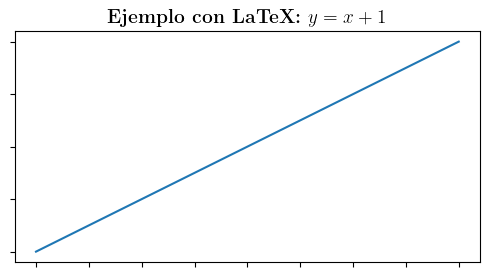

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- LaTeX rendering setup ---
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

# --- Example plot ---
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot([0,1,2], [1,2,3])

# Title rendered with LaTeX fonts
ax.set_title(r"\textbf{Ejemplo con LaTeX:} $y = x + 1$", fontsize=14)

# Remove tick labels but keep axes
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.show()

### RE ROUTE

In [2]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

### MANIFESTO

In [3]:
from scripts.utils.logger import logger

In [4]:
logger_params = {
    "main_folder": "/home/think/Desktop/MOCK",
    "experiment_name": "Consolidation",
    "date": "2025-09-07",
    "iteration": 69,
    "description": (
        "Se va a consolidar la funcion generadora "
        " de sistemas caoticos, esta sera modular."
        "Es decir, vamos a hacerlo solo para Lorenz con la posibilidad de solo tener"
        "que cambiar la defincion al principio"
        "con dos modos de generacion"
        "- Mismos params, diferentes i.c."
        "- Diferentes params, mismas i.c"
    )
}

In [5]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/MOCK/Consolidation_2025-09-07_iter69
Manifesto written to: /home/think/Desktop/MOCK/Consolidation_2025-09-07_iter69/manifesto.txt


## Step 0 : Data Generator

### Single trajectory: Idea

In [6]:
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df
import numpy as np
from scipy.integrate import solve_ivp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem

In [7]:
# Define model and params
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()      # will reload if module is already in memory
model_fixed = binder.fixer()

# Define time span 
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
# Define initial conditions
y0 = np.array([0.1, 0.1, 0.1])

# Solve each system
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

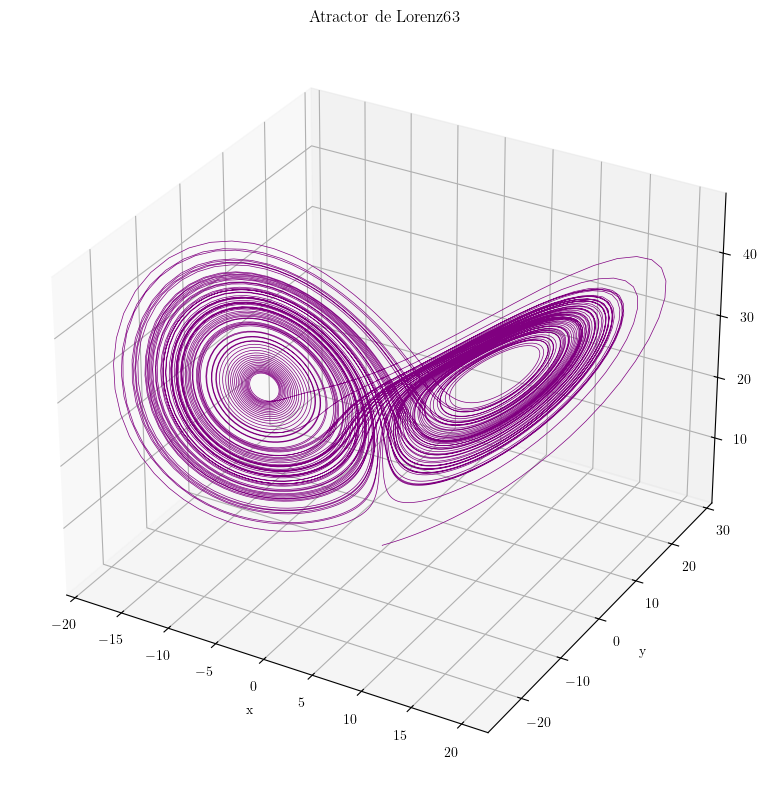

In [8]:
_ = ds1.plot(kind = '3d')

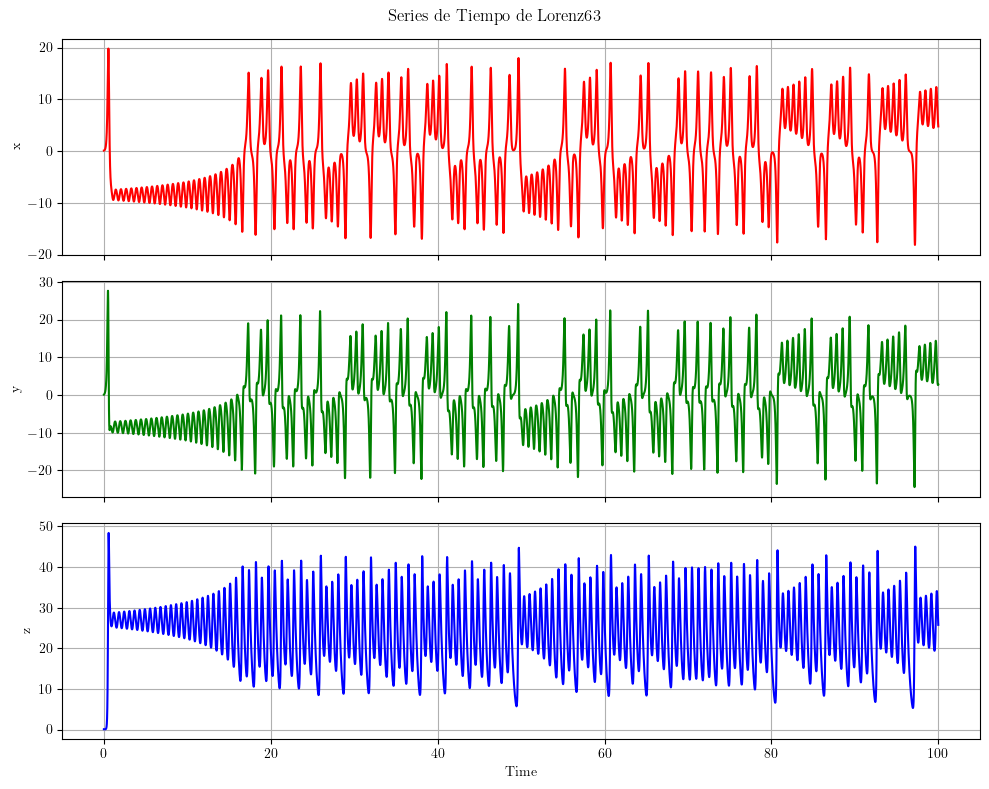

In [9]:
_ = ds1.plot(kind = 'series')

## Step 1.1 : Lyapunov Calculation

### Using RK45

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df
from scripts.data_generation.tsdg import DynamicalSystem

# --- Define model and parameters ---
model_name = 'lorenz63'
sigma = 10
beta = 8/3
rho = 28
params = (sigma, beta, rho)

# Load and fix model
binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()
model_fixed = binder.fixer()

In [11]:
# --- Initial condition ---
y0 = np.array([0.1, 0.1, 0.1])

# --- Time span ---
warmed_limit = 60
t_span = (0, warmed_limit)
n_steps = warmed_limit * 100
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

In [12]:
# --- Compute trajectories ---
ds_warmed = DynamicalSystem(model_fixed, y0, t_eval, method="RK45", notebook=True)
_ = ds_warmed.solve()

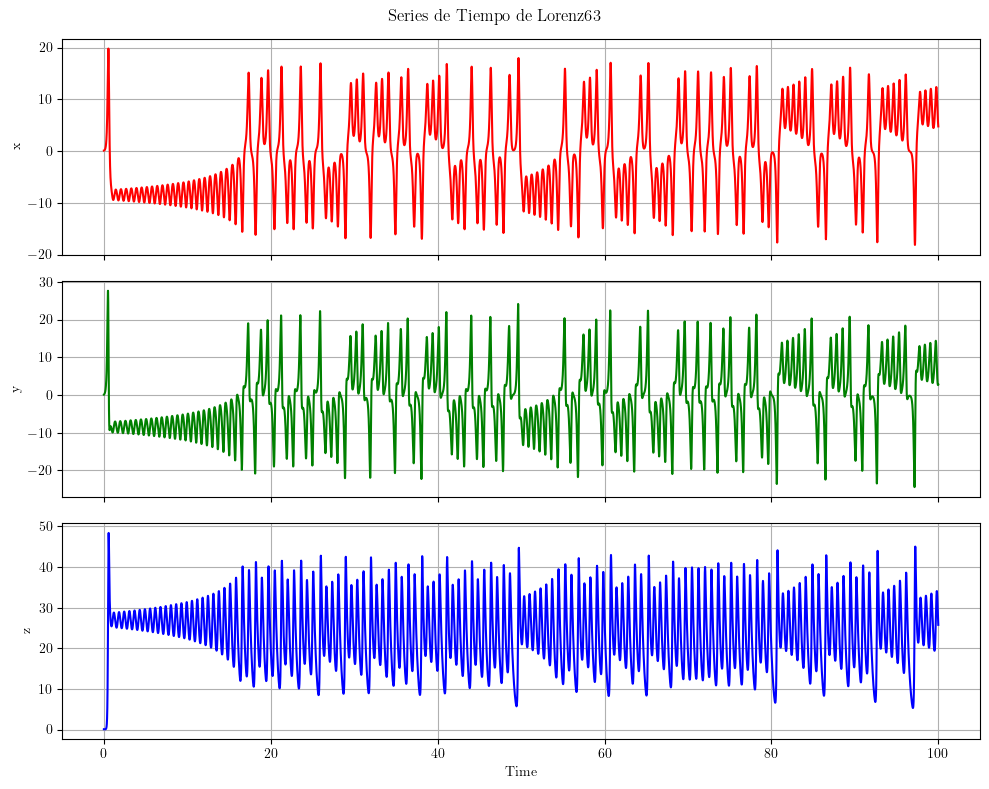

In [11]:
_ = ds_warmed.plot(kind = 'series')

Podriamos calcular la distancia con dichas trayectorias, pero tomaremos un punto fuera de la transiente, es decir, dentro del atractor.

In [106]:
y0_warmed = ds_warmed.solution.y[:, -1]
eps = 1e-8
y0_warmed_perturbed = y0_warmed + eps 

In [ ]:
# --- Time span ---
upper_limit = 100 + warmed_limit
t_span = (warmed_limit, upper_limit)
n_steps = upper_limit * 100
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

In [108]:
# --- Compute trajectories ---
ds1 = DynamicalSystem(model_fixed, y0_warmed, t_eval, notebook=True)
_ = ds1.solve()

ds2 = DynamicalSystem(model_fixed, y0_warmed_perturbed, t_eval, notebook=True)
_ = ds2.solve()

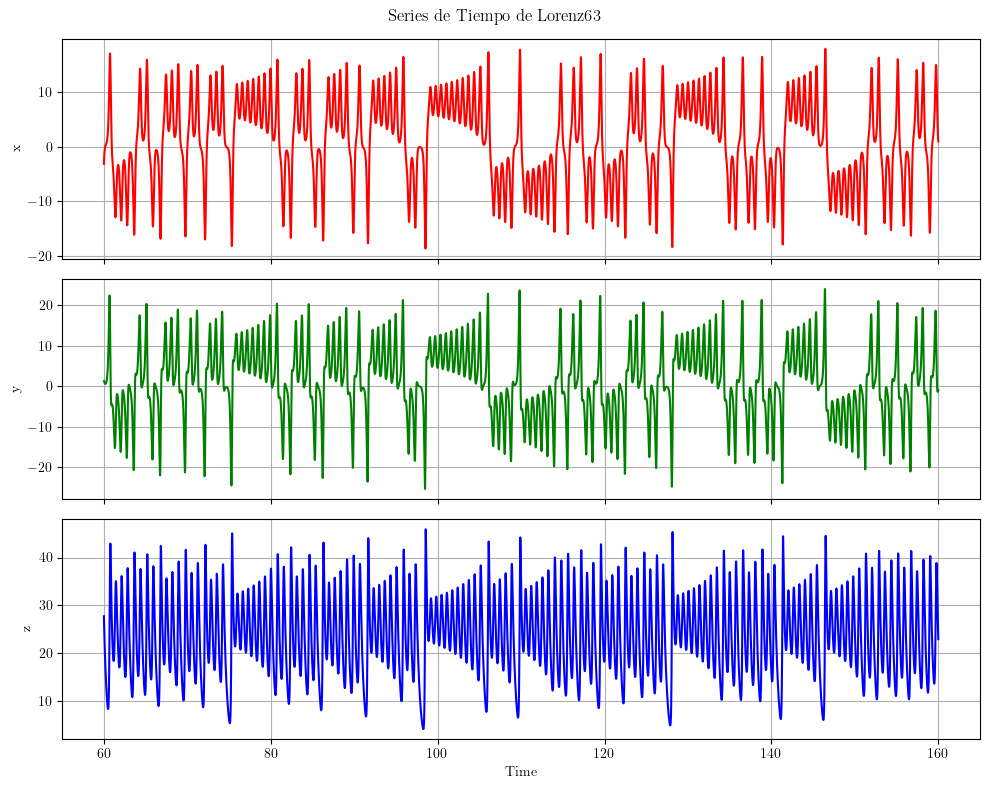

In [110]:
_ = ds1.plot(kind = 'series')

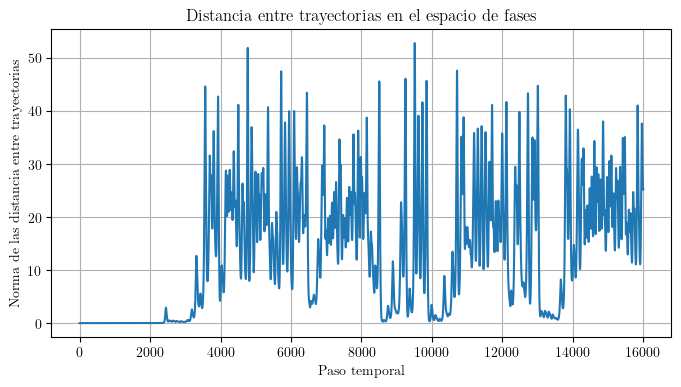

In [111]:
# --- Compute distance between trajectories ---
distance_trj = np.linalg.norm(ds2.solution.y - ds1.solution.y, axis=0)
plt.figure(figsize=(8,4))
plt.plot(distance_trj)
plt.title("Distancia entre trayectorias en el espacio de fases")
plt.ylabel('Norma de las distancia entre trayectorias')
plt.xlabel('Paso temporal')
plt.grid()
plt.show()

/tmp/ipykernel_301809/3300210858.py:4: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.semilogy(distance_trj)


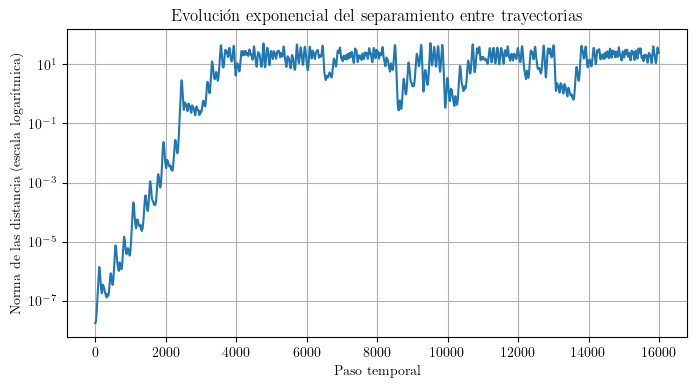

In [112]:
# --- Plot distance evolution ---
plt.figure(figsize=(8,4))
plt.axhline(y = 0, linestyle='--')
plt.semilogy(distance_trj)
plt.xlabel("Paso temporal")
plt.ylabel("Norma de las distancia (escala logarítmica)")
plt.title('Evolución exponencial del separamiento entre trayectorias ')

plt.grid()
plt.show()

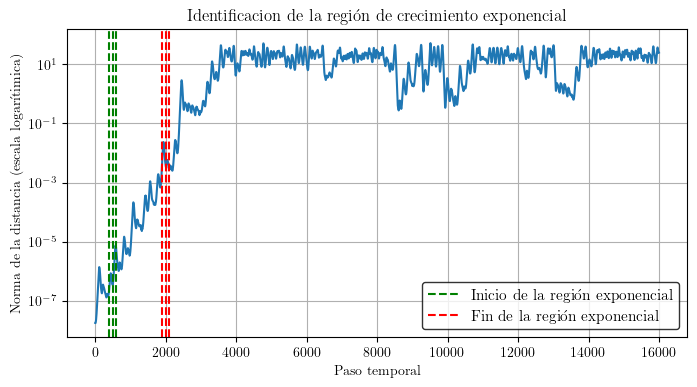

In [119]:
start_cut = 500
end_cut = 2000

spacing = 100
num_lines_each_side = 1

# Compute line positions
start_lines_left = [start_cut - spacing * i for i in range(num_lines_each_side, 0, -1)]
start_lines_right = [start_cut + spacing * i for i in range(1, num_lines_each_side + 1)]
start_all_lines = start_lines_left + [start_cut] + start_lines_right

# Compute line positions
end_lines_left = [end_cut - spacing * i for i in range(num_lines_each_side, 0, -1)]
end_lines_right = [end_cut + spacing * i for i in range(1, num_lines_each_side + 1)]
end_all_lines = end_lines_left + [end_cut] + end_lines_right

# --- Plot distance evolution ---
plt.figure(figsize=(8,4))
plt.semilogy(distance_trj)

# Plot all vertical lines with colors
for x in start_all_lines:
    color = 'green' if x == start_cut else 'green'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')

# Plot all vertical lines with colors
for x in end_all_lines:
    color = 'red' if x == end_cut else 'r'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')   

#plt.axhline(y = 10e-18, linestyle='--')
plt.xlabel("Paso temporal")
plt.ylabel("Norma de la distancia (escala logarítimica)")
#plt.xlim(0,50000)
plt.title('Identificacion de la región de crecimiento exponencial')
plt.grid()


from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0], [0],
        color='green',
        linestyle='--',
        linewidth=1.5,
        label='Inicio de la región exponencial'
    ),
    Line2D(
        [0], [0],
        color='red',
        linestyle='--',
        linewidth=1.5,
        label='Fin de la región exponencial'
    )
]

plt.legend(
    handles=legend_handles,
    loc='lower right',
    frameon=True,
    edgecolor='black',
    fontsize=11
)

plt.show()

In [120]:
# --- Lyapunov exponent via linear fit ---
# Choose first portion for linear approx np.linspace(0, 100, 200)   imation
time_points = np.arange(len(distance_trj)) * (t_eval[1] - t_eval[0])
lyapunov_exponent, log_offset = np.polyfit(time_points[start_cut:end_cut], np.log(distance_trj[start_cut:end_cut]), 1)
print("Approximate largest Lyapunov exponent:", lyapunov_exponent)

Approximate largest Lyapunov exponent: 0.9010178517851956


### Using RK4

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df
from scripts.data_generation.tsdg import DynamicalSystem

# --- Define model and parameters ---
model_name = 'lorenz63'
sigma = 10
beta = 8/3
rho = 28
params = (sigma, beta, rho)

# Load and fix model
binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()
model_fixed = binder.fixer()

In [76]:
# --- Initial condition ---
y0 = np.array([1, 1, 1])

# # --- Time span ---
# warmed_limit = 50
# t_span = (0, warmed_limit)
# n_steps = warmed_limit * 100
# t_eval = np.linspace(t_span[0], t_span[1], n_steps)

In [77]:
class RK4Stepper:
    def __init__(self, f_fixed, dt=0.01):
        """
        Parameters:
        -----------
        f_fixed : callable
            Function with parameters already bound (from Binder.fixer())
            Should have signature f_fixed(t, state) -> derivative
        dt : float
            Time step size
        """
        self.f = f_fixed
        self.dt = dt
    
    def __call__(self, t, u_prev):
        """
        Single RK4 step.
        
        Parameters:
        -----------
        t : float
            Current time
        u_prev : array-like
            Current state
            
        Returns:
        --------
        u_next : array
            Next state
        """
        h = self.dt
        k1 = self.f(t, u_prev)
        k2 = self.f(t + 0.5*h, u_prev + 0.5*h*np.array(k1))
        k3 = self.f(t + 0.5*h, u_prev + 0.5*h*np.array(k2))
        k4 = self.f(t + h, u_prev + h*np.array(k3))
        
        u_next = u_prev + (h/6)*(np.array(k1) + 2*np.array(k2) + 2*np.array(k3) + np.array(k4))
        return u_next
    
    def integrate(self, y0, t_eval):
        """
        Integrate over multiple time steps.
        
        Parameters:
        -----------
        y0 : array-like
            Initial state
        t_eval : array-like
            Time points to evaluate at
            
        Returns:
        --------
        trajectory : ndarray
            Array of shape (n_dims, n_steps) containing the trajectory
        """
        trajectory = [np.array(y0)]
        
        for i in range(1, len(t_eval)):
            t_current = t_eval[i-1]
            u_next = self(t_current, trajectory[-1])
            trajectory.append(u_next)
        
        return np.array(trajectory).T  # Shape: (n_dims, n_steps)

In [78]:
import numpy as np

def round_to_first_nonzero(value):
    """Round to the first non-zero decimal place."""
    if value == 0:
        return 0
    # Find the order of magnitude
    magnitude = np.floor(np.log10(np.abs(value)))
    # Round to that precision
    decimals = int(-magnitude)
    return np.round(value, decimals)

In [79]:
# Your time setup
warmed_limit = 50
t_span = (0, warmed_limit)
n_steps = warmed_limit * 100
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

# Bind parameters
binder = Binder(f"scripts.systems.{model_name}", model_name, params)
binder.import_module()
model_fixed = binder.fixer()

# Calculate dt from your t_eval
dt = round_to_first_nonzero(t_eval[1] - t_eval[0])
# Create stepper
stepper = RK4Stepper(model_fixed, dt=dt)

# # Initial condition
# y0 = np.array([0.1, 0.1, 0.1])

# Integrate!
warmed_trajectory = stepper.integrate(y0, t_eval)

In [80]:
dt

0.01

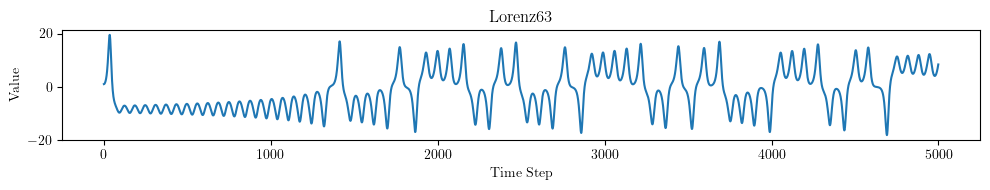

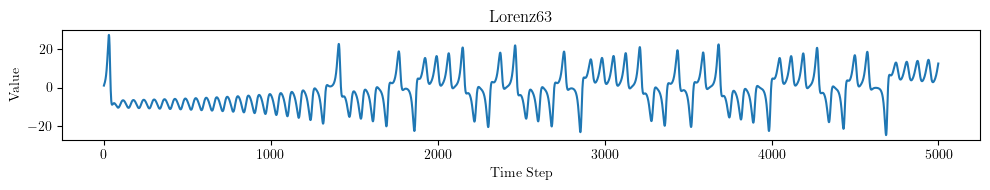

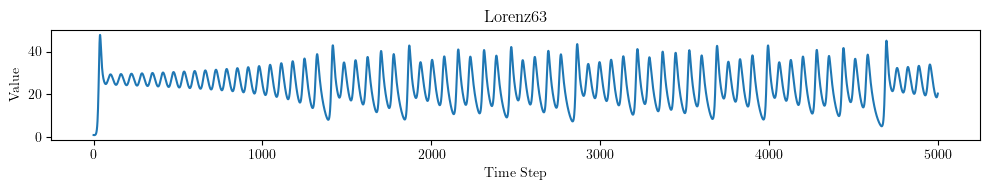

In [81]:
for i in range(3):

    plt.figure(figsize=(10, 2))
    plt.plot(warmed_trajectory[i,:])
    plt.title("Lorenz63")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

In [82]:
y0_warmed = warmed_trajectory[:, -1]
eps = 1e-8
y0_warmed_perturbed = y0_warmed + eps 

In [83]:
# --- Time span ---
upper_limit = 50 + warmed_limit
t_span = (warmed_limit, upper_limit)
n_steps = (upper_limit - warmed_limit) * 100
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

In [84]:
t_span

(50, 100)

In [85]:
n_steps

5000

In [86]:
# Calculate dt from your t_eval
dt = round_to_first_nonzero(t_eval[1] - t_eval[0])
# Create stepper
stepper = RK4Stepper(model_fixed, dt=dt)

In [87]:
# --- Compute trajectories ---
ds1 = stepper.integrate(y0_warmed, t_eval)

ds2 = stepper.integrate(y0_warmed_perturbed, t_eval)

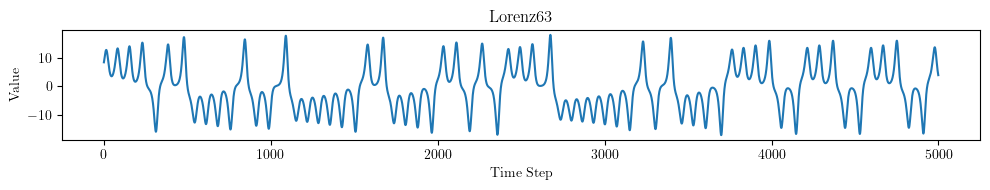

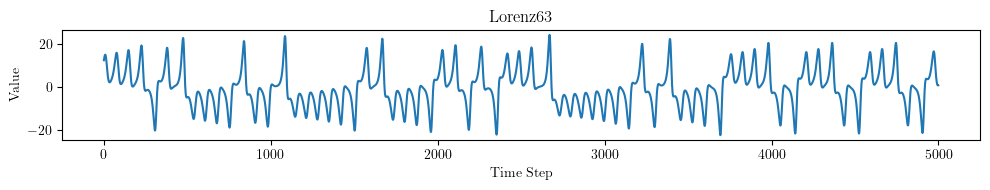

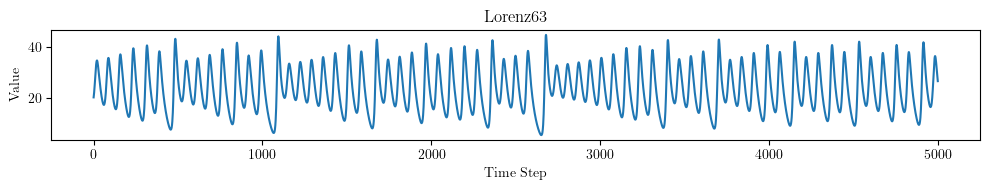

In [88]:
for i in range(3):

    plt.figure(figsize=(10, 2))
    plt.plot(ds2[i,:])
    plt.title("Lorenz63")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

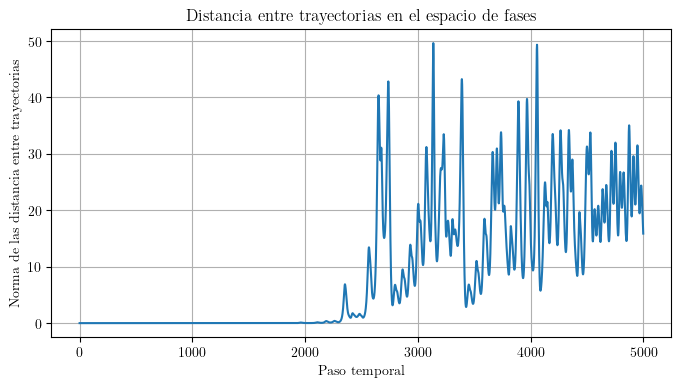

In [89]:
# --- Compute distance between trajectories ---
distance_trj = np.linalg.norm(ds2 - ds1, axis=0)
plt.figure(figsize=(8,4))
plt.plot(distance_trj)
plt.title("Distancia entre trayectorias en el espacio de fases")
plt.ylabel('Norma de las distancia entre trayectorias')
plt.xlabel('Paso temporal')
plt.grid()
plt.show()

/tmp/ipykernel_314019/427366610.py:4: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.semilogy(distance_trj)


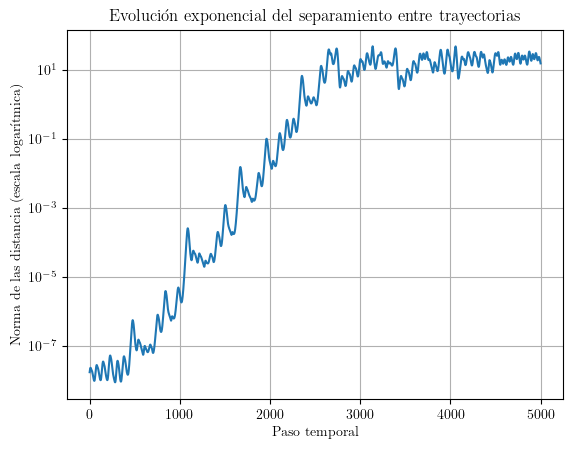

In [95]:
# --- Plot distance evolution ---
# plt.figure(figsize=(8,4))
plt.axhline(y = 0, linestyle='--')
plt.semilogy(distance_trj)
plt.xlabel("Paso temporal")
plt.ylabel("Norma de las distancia (escala logarítmica)")
plt.title('Evolución exponencial del separamiento entre trayectorias ')

plt.grid()
plt.show()

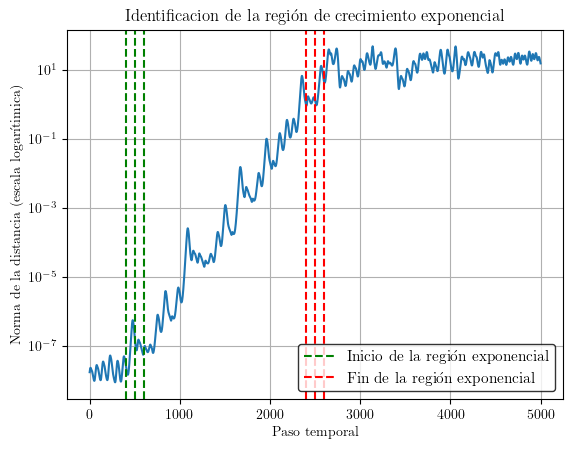

In [96]:
start_cut = 500
end_cut = 2500

spacing = 100
num_lines_each_side = 1

# Compute line positions
start_lines_left = [start_cut - spacing * i for i in range(num_lines_each_side, 0, -1)]
start_lines_right = [start_cut + spacing * i for i in range(1, num_lines_each_side + 1)]
start_all_lines = start_lines_left + [start_cut] + start_lines_right

# Compute line positions
end_lines_left = [end_cut - spacing * i for i in range(num_lines_each_side, 0, -1)]
end_lines_right = [end_cut + spacing * i for i in range(1, num_lines_each_side + 1)]
end_all_lines = end_lines_left + [end_cut] + end_lines_right

# --- Plot distance evolution ---
# plt.figure(figsize=(8,4))
plt.semilogy(distance_trj)

# Plot all vertical lines with colors
for x in start_all_lines:
    color = 'green' if x == start_cut else 'green'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')

# Plot all vertical lines with colors
for x in end_all_lines:
    color = 'red' if x == end_cut else 'r'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')   

#plt.axhline(y = 10e-18, linestyle='--')
plt.xlabel("Paso temporal")
plt.ylabel("Norma de la distancia (escala logarítimica)")
#plt.xlim(0,50000)
plt.title('Identificacion de la región de crecimiento exponencial')
plt.grid()


from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0], [0],
        color='green',
        linestyle='--',
        linewidth=1.5,
        label='Inicio de la región exponencial'
    ),
    Line2D(
        [0], [0],
        color='red',
        linestyle='--',
        linewidth=1.5,
        label='Fin de la región exponencial'
    )
]

plt.legend(
    handles=legend_handles,
    loc='lower right',
    frameon=True,
    edgecolor='black',
    fontsize=11
)

plt.show()

In [97]:
# --- Lyapunov exponent via linear fit ---
# Choose first portion for linear approx np.linspace(0, 100, 200)   imation
time_points = np.arange(len(distance_trj)) * (t_eval[1] - t_eval[0])
lyapunov_exponent, log_offset = np.polyfit(time_points[start_cut:end_cut], np.log(distance_trj[start_cut:end_cut]), 1)
print("Approximate largest Lyapunov exponent:", lyapunov_exponent)

Approximate largest Lyapunov exponent: 0.894399527838906


### Stress Test on Diff i.c's for same params.
For Different inital conditions and same parameters the lyapunov exponent should be the same

In [ ]:
# # --- Initial condition and perturbation ---
# n_density = 200
# # x =  np.linspace(0, 100, n_density)
# x = np.round(np.linspace(0, 100, n_density), 1)
# y = x
# z = x
# initial_conditions = list()
# for i in range(n_density):
#     # print(x[i],y[i],z[i])
#     initial_conditions.append([x[i],y[i],z[i]])

# initial_conditions = np.array(initial_conditions) 
# # y0 = np.array([1, 1, 1])

# n_density = 200
# x = np.round(np.linspace(0, 100, n_density), 1)
# initial_conditions = np.column_stack([x, x, x])

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Original parameters
sigma = 10
beta = 8/3
rho = 28  

params = (sigma, beta, rho)

# --- Initial condition and perturbation ---
n_density = 10
x = np.round(np.linspace(0, 100, n_density), 1)
initial_conditions = np.column_stack([x, x, x])

eps = 1e-8

# --- Time span ---
t_span = (0, 100)
n_steps = 10000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

# folder to save images
save_path = f"{exp_folder}/lyap_images"

# create folder if it doesn't exist
os.makedirs(save_path, exist_ok=True)



for i, j in enumerate(initial_conditions):

    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    y0 = j

    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    dist = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)

    # --- plot ---
    plt.figure(figsize=(8,4))
    plt.semilogy(t_eval, dist)
    plt.grid(True)
    plt.xlabel("time")
    plt.ylabel("distance")
    plt.title(f"Iteration {i} — rho={rho:.3f}")

    # --- save ---
    filename = f"{i}.png"
    filepath = os.path.join(save_path, filename)
    plt.savefig(filepath, dpi=200, bbox_inches='tight')

    plt.close()   # close figure so memory doesn’t explode

Text(0.5, 1.0, 'Iteration 9 — rho=28.000')

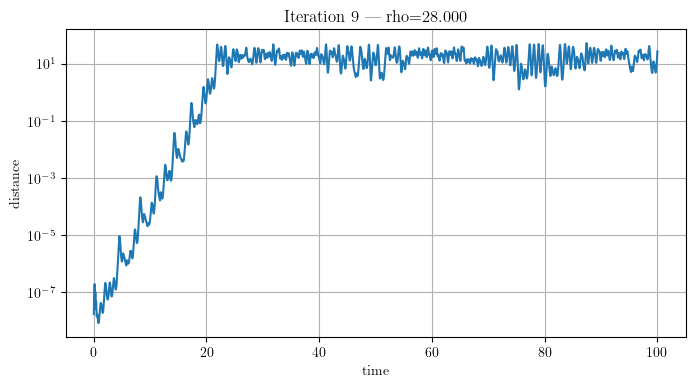

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Original parameters
sigma = 10
beta = 8/3
rho = 28  

params = (sigma, beta, rho)

# --- Initial condition and perturbation ---
n_density = 10
x = np.round(np.linspace(0, 100, n_density), 1)
initial_conditions = np.column_stack([x, x, x])

eps = 1e-8

# --- Time span ---
t_span = (0, 100)
n_steps = 10000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

for i, j in enumerate(initial_conditions):

    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    y0 = j

    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    dist = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)

# --- plot ---
plt.figure(figsize=(8,4))
plt.semilogy(t_eval, dist)
plt.grid(True)
plt.xlabel("time")
plt.ylabel("distance")
plt.title(f"Iteration {i} — rho={rho:.3f}")

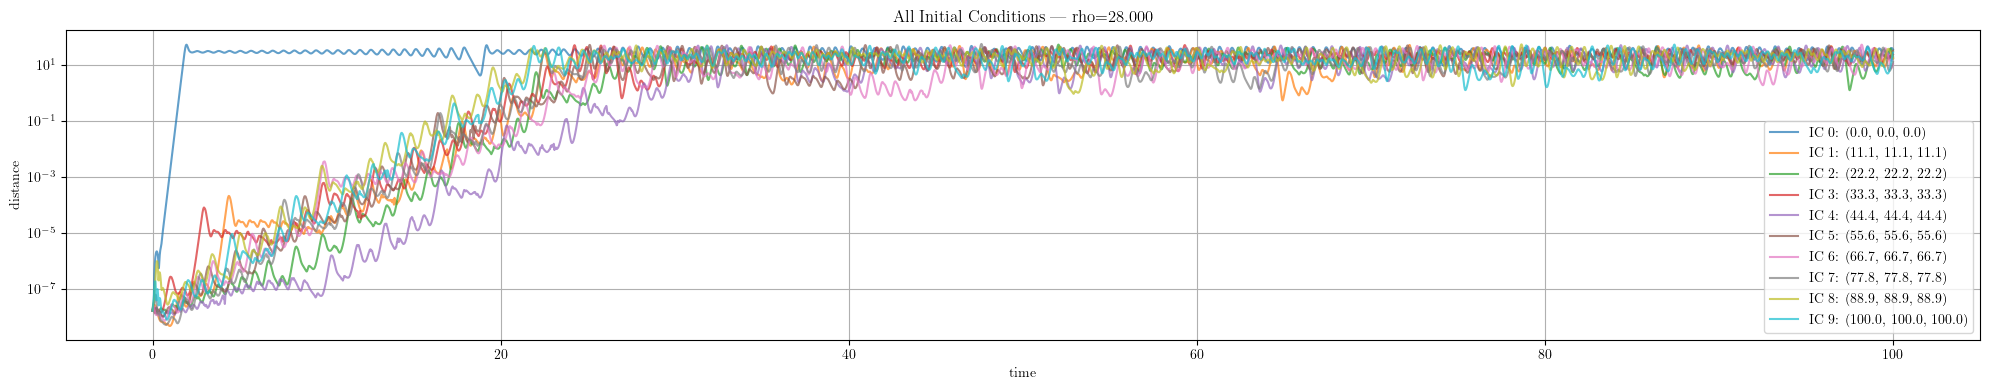

In [48]:
plt.figure(figsize=(20,4))

for i, j in enumerate(initial_conditions):
    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    y0 = j
    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    dist = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)
    
    # Plot each iteration on the same axes
    plt.semilogy(t_eval, dist, label=f"IC {i}: ({j[0]}, {j[1]}, {j[2]})", alpha=0.7)

plt.grid(True)
plt.xlabel("time")
plt.ylabel("distance")
plt.title(f"All Initial Conditions — rho={rho:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


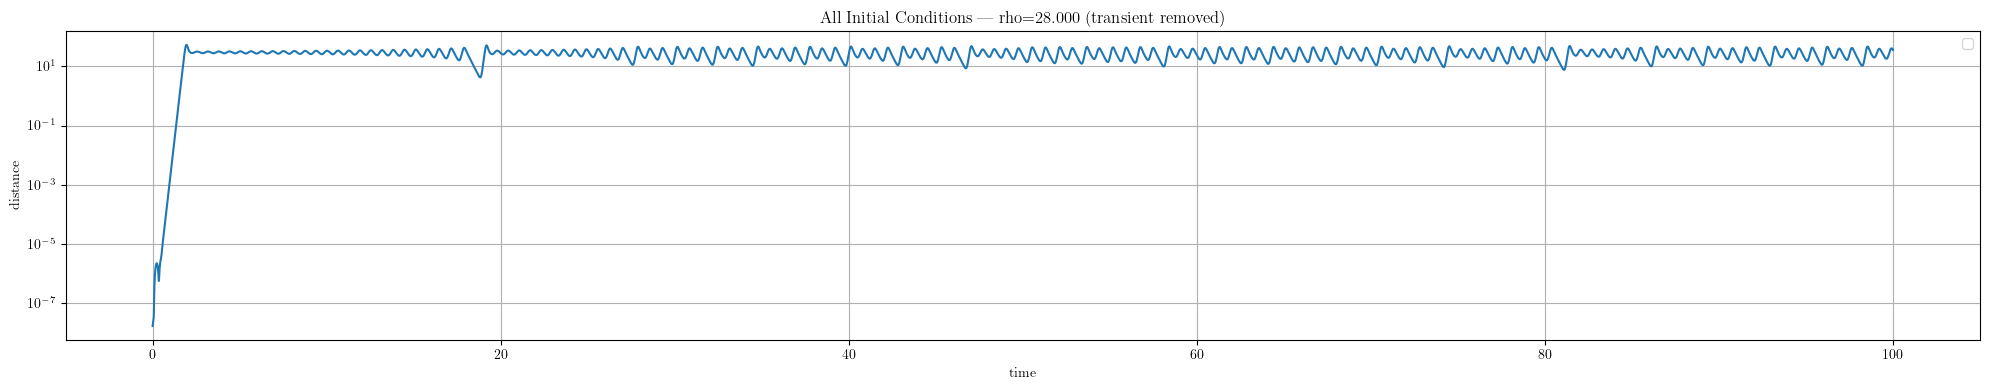

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Original parameters
sigma = 10
beta = 8/3
rho = 28  

params = (sigma, beta, rho)

# --- Initial condition and perturbation ---
n_density = 1
x = np.round(np.linspace(0, 100, n_density), 1)
initial_conditions = np.column_stack([x, x, x])

eps = 1e-8

# --- Time span ---
t_span = (0, 100)
n_steps = 10000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

plt.figure(figsize=(20,4))

for[2000:] i, j in enumerate(initial_conditions):

    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    y0 = j

    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    # --- Discard transient (first 20 time units = first 2000 points) ---
    transient_cutoff = 0
    t_eval_trimmed = t_eval[transient_cutoff:]
    dist_trimmed = dist[transient_cutoff:]



    dist_trimmed = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)
    
    

    # Plot each iteration on the same axes
    plt.semilogy(t_eval_trimmed, dist_trimmed)

    # # Plot each iteration on the same axes
    # plt.semilogy(t_eval, dist, label=f"IC {i}: ({j[0]}, {j[1]}, {j[2]})", alpha=0.7)


plt.grid(True)
plt.xlabel("time")
plt.ylabel("distance")
plt.title(f"All Initial Conditions — rho={rho:.3f} (transient removed)")
# plt.legend()
plt.tight_layout()
plt.show()

In [55]:
ds1_rho.solution.y.shape

(3, 10000)

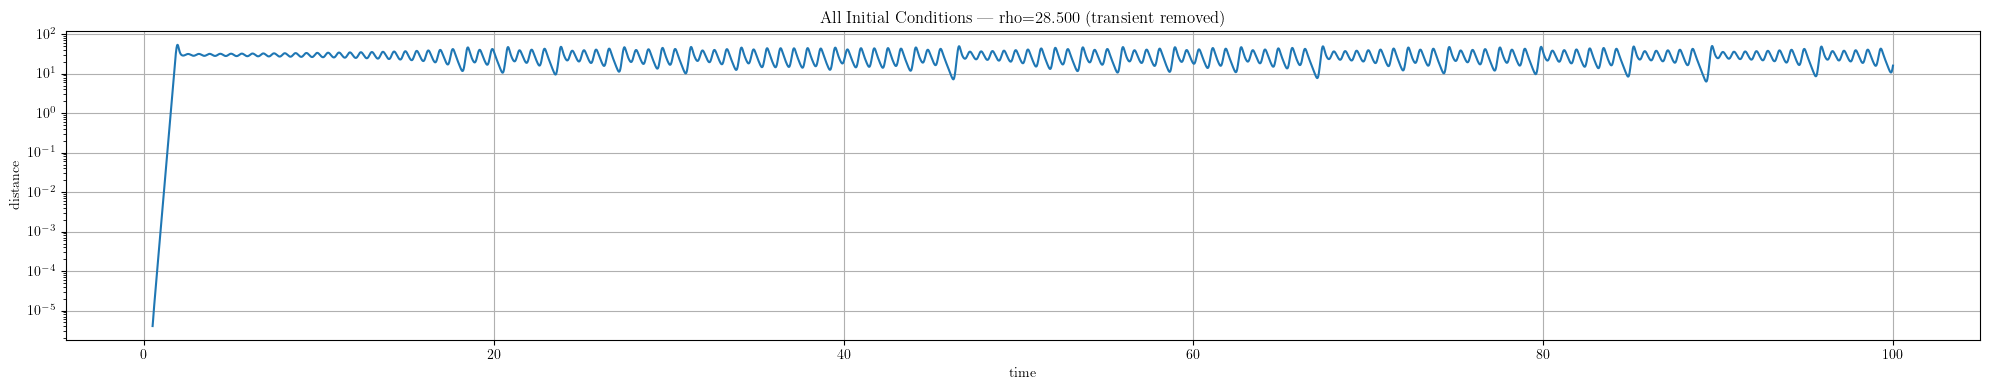

In [60]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Original parameters
sigma = 10
beta = 8/3
rho = 28.5  

params = (sigma, beta, rho)

# --- Initial condition and perturbation ---
n_density = 1
x = np.round(np.linspace(0, 100, n_density), 1)
initial_conditions = np.column_stack([x, x, x])

eps = 1e-8

# --- Time span ---
t_span = (0, 100)
n_steps = 10000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

plt.figure(figsize=(20,4))

# --- Discard transient (first 20 time units = first 2000 points) ---
transient_cutoff = 50

for i, j in enumerate(initial_conditions):

    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    y0 = j

    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    # Trim the trajectories along the TIME axis (axis=1 or axis=-1)
    # Assuming solution.y has shape (3, n_steps)
    traj1_trimmed = ds1_rho.solution.y[:, transient_cutoff:]
    traj2_trimmed = ds2_rho.solution.y[:, transient_cutoff:]
    t_eval_trimmed = t_eval[transient_cutoff:]
    
    # Now compute distance on the trimmed trajectories
    dist_trimmed = np.linalg.norm(traj1_trimmed - traj2_trimmed, axis=0)

    # Plot each iteration on the same axes
    plt.semilogy(t_eval_trimmed, dist_trimmed)


plt.grid(True)
plt.xlabel("time")
plt.ylabel("distance")
plt.title(f"All Initial Conditions — rho={rho:.3f} (transient removed)")
plt.tight_layout()
plt.show()

### Using a more robust approach 

Lyaoun

### Granlarity effects on Lyapunov Exponent calculation

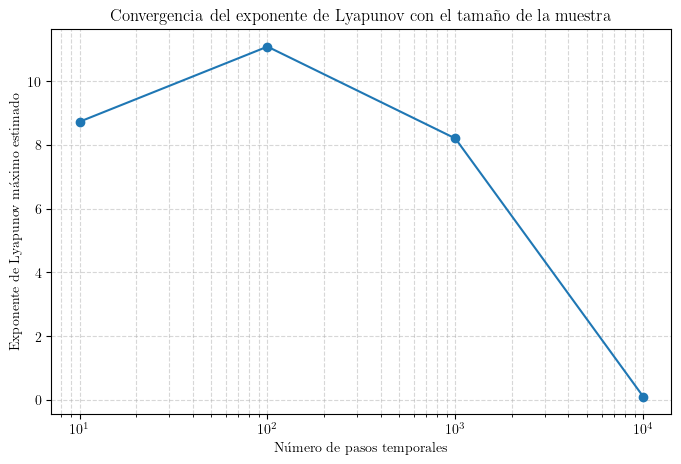

In [148]:
import numpy as np
import matplotlib.pyplot as plt

# --- parameters for LE estimation ---
min_power = 1       # 10^1
max_power = 6       # 10^6 (increase if you really want)
start_cut_frac = 0.2
end_cut_frac   = 0.6

dt = t_eval[1] - t_eval[0]

n_steps_list = []
lyap_list = []

for p in range(min_power, max_power + 1):

    n_steps = int(10**p)

    # safety check
    if n_steps >= len(distance_trj):
        break

    # define fitting window
    start_cut = int(start_cut_frac * n_steps)
    end_cut   = int(end_cut_frac * n_steps)

    # time vector
    time_points = np.arange(n_steps) * dt

    # linear fit in log-space
    coeffs = np.polyfit(
        time_points[start_cut:end_cut],
        np.log(distance_trj[start_cut:end_cut]),
        1
    )

    lyapunov_exponent = coeffs[0]

    n_steps_list.append(n_steps)
    lyap_list.append(lyapunov_exponent)

# --- Plot ---
plt.figure(figsize=(8, 5))

plt.plot(
    n_steps_list,
    lyap_list,
    marker='o',
    linewidth=1.5
)

plt.xscale('log')

plt.xlabel('Número de pasos temporales')
plt.ylabel('Exponente de Lyapunov máximo estimado')
plt.title('Convergencia del exponente de Lyapunov con el tamaño de la muestra')

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_generation.tsdg import DynamicalSystem


def lyapunov_vs_nsteps(
    model_fixed,
    y0,
    eps=1e-8,
    t_span=(0, 100),
    n_steps_min=100,
    n_steps_max=10**8,
    step_size=50,
    fit_start_frac=0.2,
    fit_end_frac=0.6,
):
    """
    Computes the largest Lyapunov exponent as a function of n_steps
    by recomputing the full dynamical system each time.

    Parameters
    ----------
    model_fixed : callable
        Lorenz (or other) system RHS
    y0 : ndarray
        Initial condition
    eps : float
        Perturbation magnitude
    t_span : tuple
        Time interval
    n_steps_min : int
        Minimum number of time steps
    n_steps_max : int
        Maximum number of time steps
    step_size : int
        Increment in n_steps (granularity)
    fit_start_frac : float
        Fraction of trajectory where linear fit starts
    fit_end_frac : float
        Fraction of trajectory where linear fit ends
    """

    y0_perturbed = y0 + eps

    n_steps_values = np.arange(n_steps_min, n_steps_max + 1, step_size)
    lyapunov_values = []

    for n_steps in n_steps_values:
        print(f"Computing n_steps = {n_steps}")

        t_eval = np.linspace(t_span[0], t_span[1], n_steps)

        ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook=False)
        ds1.solve()

        ds2 = DynamicalSystem(model_fixed, y0_perturbed, t_eval, notebook=False)
        ds2.solve()

        distance_trj = np.linalg.norm(
            ds2.solution.y - ds1.solution.y,
            axis=0
        )

        # avoid log(0)
        valid = distance_trj > 0
        distance_trj = distance_trj[valid]
        t_valid = t_eval[valid]

        i_start = int(fit_start_frac * len(distance_trj))
        i_end   = int(fit_end_frac * len(distance_trj))

        time_points = t_valid - t_valid[0]

        lyap, _ = np.polyfit(
            time_points[i_start:i_end],
            np.log(distance_trj[i_start:i_end]),
            1
        )

        lyapunov_values.append(lyap)

    return n_steps_values, np.array(lyapunov_values)


In [156]:
n_steps_vals, lyap_vals = lyapunov_vs_nsteps(
    model_fixed=model_fixed,
    y0=y0,
    eps=1e-8,
    t_span=(0, 100),
    n_steps_min=100,
    n_steps_max=10**6,   # push as far as your machine allows
    step_size=10**4,        # granularity knob
    fit_start_frac=0.2,
    fit_end_frac=0.4
)


Computing n_steps = 100
Computing n_steps = 10100
Computing n_steps = 20100
Computing n_steps = 30100
Computing n_steps = 40100
Computing n_steps = 50100
Computing n_steps = 60100
Computing n_steps = 70100
Computing n_steps = 80100
Computing n_steps = 90100
Computing n_steps = 100100
Computing n_steps = 110100
Computing n_steps = 120100
Computing n_steps = 130100
Computing n_steps = 140100
Computing n_steps = 150100
Computing n_steps = 160100
Computing n_steps = 170100
Computing n_steps = 180100
Computing n_steps = 190100
Computing n_steps = 200100
Computing n_steps = 210100
Computing n_steps = 220100
Computing n_steps = 230100
Computing n_steps = 240100
Computing n_steps = 250100
Computing n_steps = 260100
Computing n_steps = 270100
Computing n_steps = 280100
Computing n_steps = 290100
Computing n_steps = 300100
Computing n_steps = 310100
Computing n_steps = 320100
Computing n_steps = 330100
Computing n_steps = 340100
Computing n_steps = 350100
Computing n_steps = 360100
Computing n_s

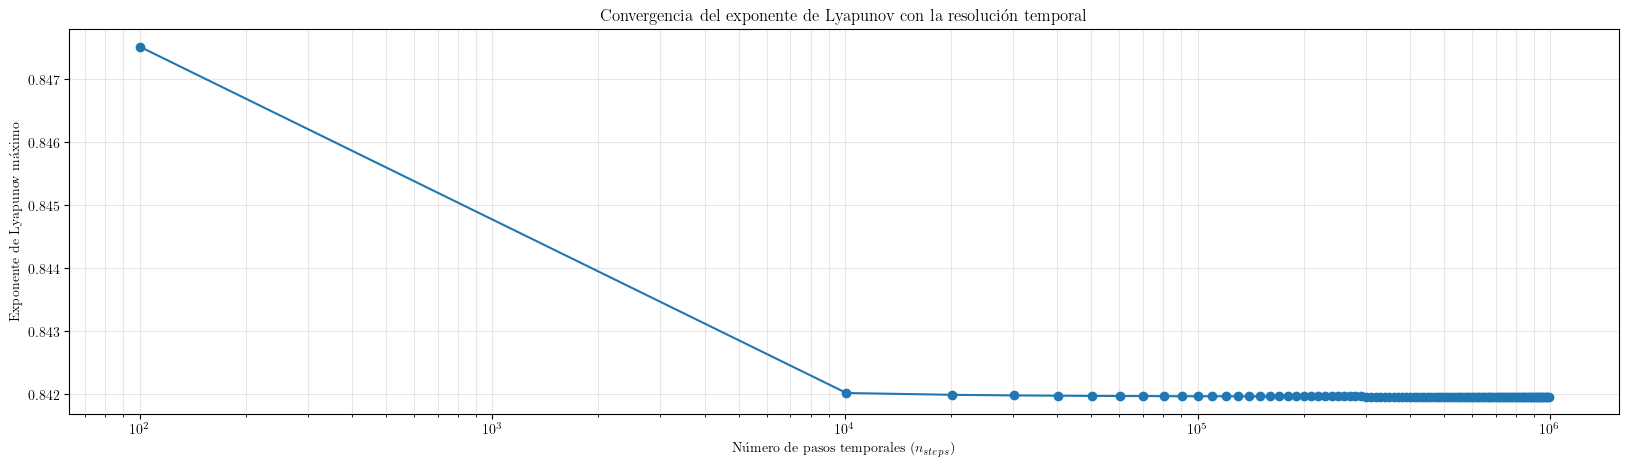

In [158]:
plt.figure(figsize=(20, 5))
plt.plot(n_steps_vals, lyap_vals, marker='o', linewidth=1.5)
plt.xscale('log')
plt.xlabel('Número de pasos temporales ($n_{steps}$)')
plt.ylabel('Exponente de Lyapunov máximo')
plt.title('Convergencia del exponente de Lyapunov con la resolución temporal')
plt.grid(True, which='both', alpha=0.3)
plt.show()


## Step 1.2 : Lyapunov Sweeping for Rho (or any parameter)

In [15]:
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df
import numpy as np
from scipy.integrate import solve_ivp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem

### A very naive sweep
The linear region is fixed

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Original parameters
sigma = 10
beta = 8/3
rho_values = np.linspace(0, 100, 1000)  
params_base = (sigma, beta, None)    # placeholder for rho


# --- Initial condition and perturbation ---
y0 = np.array([1, 1, 1])
eps = 1e-8

# --- Time span ---
t_span = (0, 200)
n_steps = 20000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)


# Store Lyapunov exponents
lambda_max_list = []

# Loop over rho
for rho in rho_values:
    # Update model with new rho
    params = (sigma, beta, rho)
    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()
    
    # Solve trajectories (keep y0 same)
    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    _ = ds1_rho.solve()
    
    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    _ = ds2_rho.solve()
    
    # Compute separation
    delta = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)
    t = ds1_rho.solution.t
    
    # Linear fit window (after transient)
    linear_idx = (t > transient) & (t < fit_end)
    t_linear = t[linear_idx]
    delta_linear = delta[linear_idx]
    
    # Linear fit of log(delta) to get Lyapunov exponent
    slope, intercept = np.polyfit(t_linear, np.log(delta_linear), 1)
    lambda_max_list.append(slope)

NameError: name 'transient' is not defined

In [ ]:
# --- Compute distance between trajectories ---
distance_trj = np.linalg.norm(ds2.solution.y - ds1.solution.y, axis=0)

# --- Plot distance evolution ---
plt.figure(figsize=(8,4))
plt.axhline(y = 0, linestyle='--')
plt.semilogy(distance_trj)
plt.xlabel("time step")
plt.ylabel("distance norm")

plt.grid()
plt.show()

### Logarithmic plot for different rho's

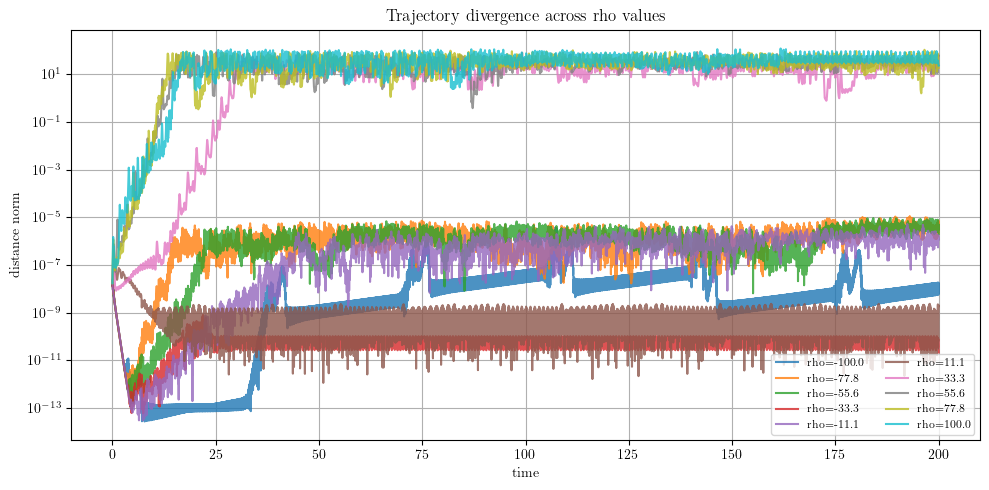

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# pick about 10 values instead of thousands
rho_sample = np.linspace(-100, 100, 10)  

plt.figure(figsize=(10,5))

for rho in rho_sample:
    params = (sigma, beta, rho)
    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    # solve unperturbed
    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    # solve perturbed
    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    # compute distance curve
    dist = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)

    # plot each trajectory separation
    plt.semilogy(t_eval, dist, alpha=0.8, label=f"rho={rho:.1f}")

plt.xlabel("time")
plt.ylabel("distance norm")
plt.title("Trajectory divergence across rho values")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [193]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Original parameters
sigma = 10
beta = 8/3
rho_sample = np.linspace(0, 100, 200)   # choose 10 values (or whatever you want)

# --- Initial condition and perturbation ---
y0 = np.array([1, 1, 1])
eps = 1e-8

# --- Time span ---
t_span = (0, 300)
n_steps = 30000
t_eval = np.linspace(t_span[0], t_span[1], n_steps)

# folder to save images
save_path = f"{exp_folder}/lyap_images"

# create folder if it doesn't exist
os.makedirs(save_path, exist_ok=True)

for i, rho in enumerate(rho_sample):

    params = (sigma, beta, rho)
    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()

    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    dist = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)

    # --- plot ---
    plt.figure(figsize=(8,4))
    plt.semilogy(t_eval, dist)
    plt.grid(True)
    plt.xlabel("time")
    plt.ylabel("distance")
    plt.title(f"Iteration {i} — rho={rho:.3f}")

    # --- save ---
    filename = f"{i}.png"
    filepath = os.path.join(save_path, filename)
    plt.savefig(filepath, dpi=200, bbox_inches='tight')

    plt.close()   # close figure so memory doesn’t explode

In [ ]:
start_cut = 20000
end_cut = 40000

spacing = 1000
num_lines_each_side = 1

# Compute line positions
start_lines_left = [start_cut - spacing * i for i in range(num_lines_each_side, 0, -1)]
start_lines_right = [start_cut + spacing * i for i in range(1, num_lines_each_side + 1)]
start_all_lines = start_lines_left + [start_cut] + start_lines_right

# Compute line positions
end_lines_left = [end_cut - spacing * i for i in range(num_lines_each_side, 0, -1)]
end_lines_right = [end_cut + spacing * i for i in range(1, num_lines_each_side + 1)]
end_all_lines = end_lines_left + [end_cut] + end_lines_right

# --- Plot distance evolution ---
plt.figure(figsize=(8,4))
plt.semilogy(distance_trj)

# Plot all vertical lines with colors
for x in start_all_lines:
    color = 'green' if x == start_cut else 'green'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')

# Plot all vertical lines with colors
for x in end_all_lines:
    color = 'red' if x == end_cut else 'r'  # black for obo, red for others
    plt.axvline(x=x, color=color, linestyle='--')   

#plt.axhline(y = 10e-18, linestyle='--')
plt.xlabel("Paso temporal")
plt.ylabel("Norma de la distancia (escala logarítimica)")
#plt.xlim(0,50000)
plt.title('Identificacion de la región de crecimiento exponencial')
plt.grid()


from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0], [0],
        color='green',
        linestyle='--',
        linewidth=1.5,
        label='Inicio de la región exponencial'
    ),
    Line2D(
        [0], [0],
        color='red',
        linestyle='--',
        linewidth=1.5,
        label='Fin de la región exponencial'
    )
]

plt.legend(
    handles=legend_handles,
    loc='lower right',
    frameon=True,
    edgecolor='black',
    fontsize=11
)

plt.show()

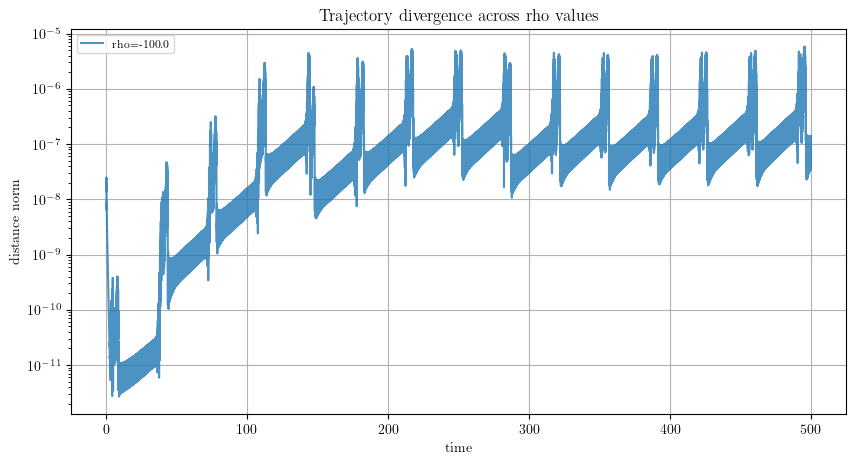

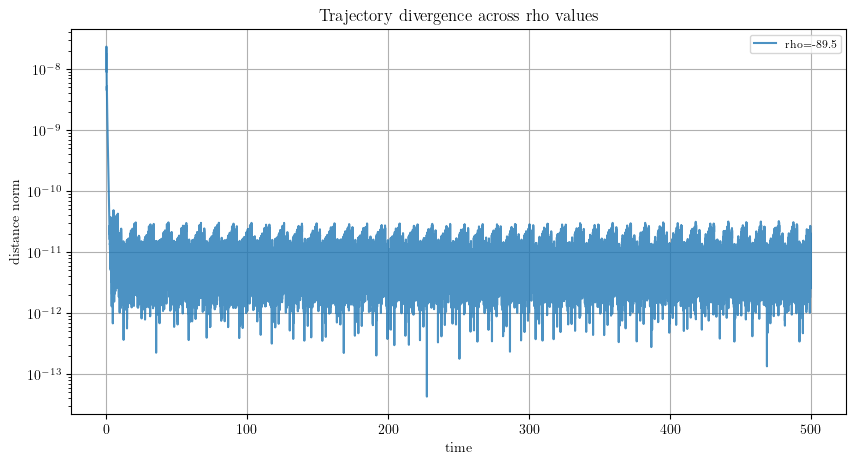

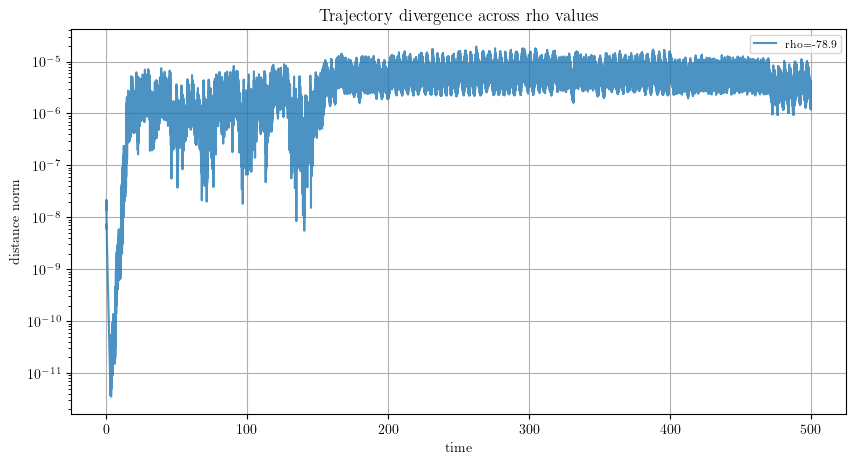

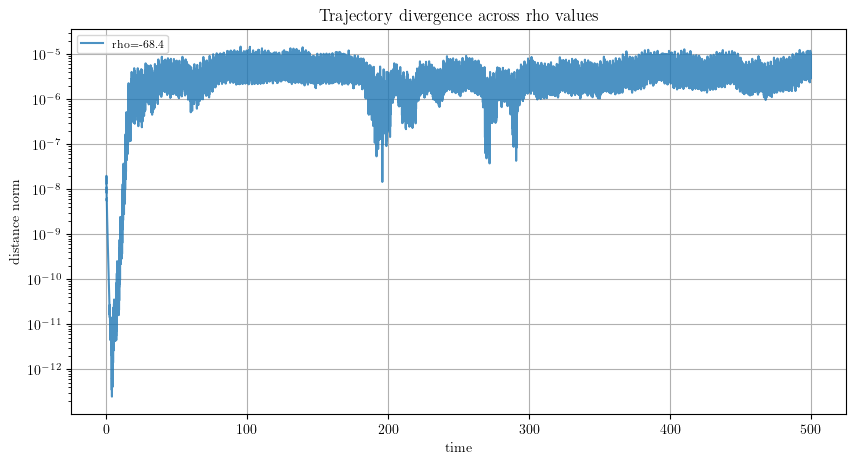

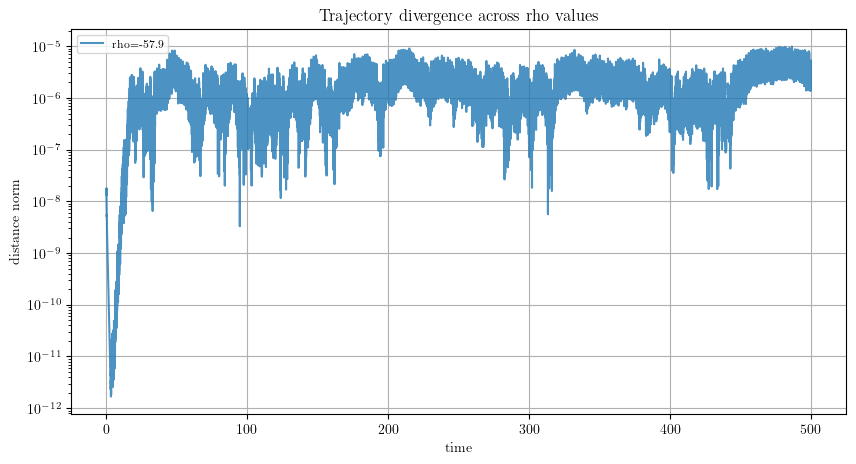

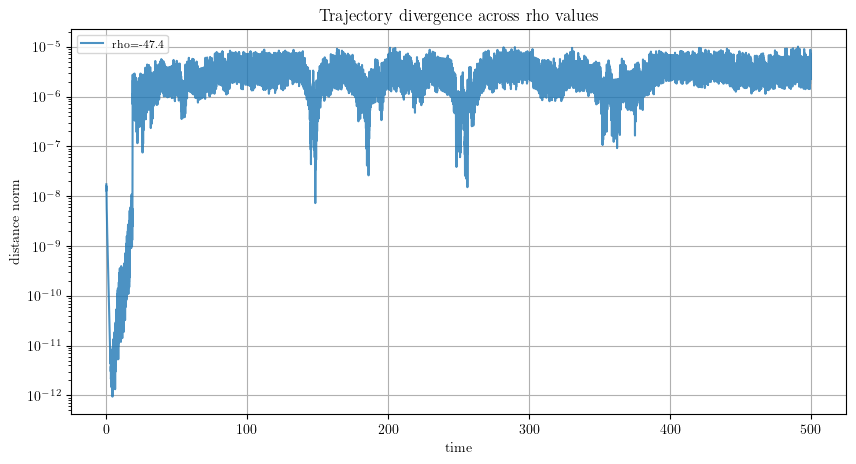

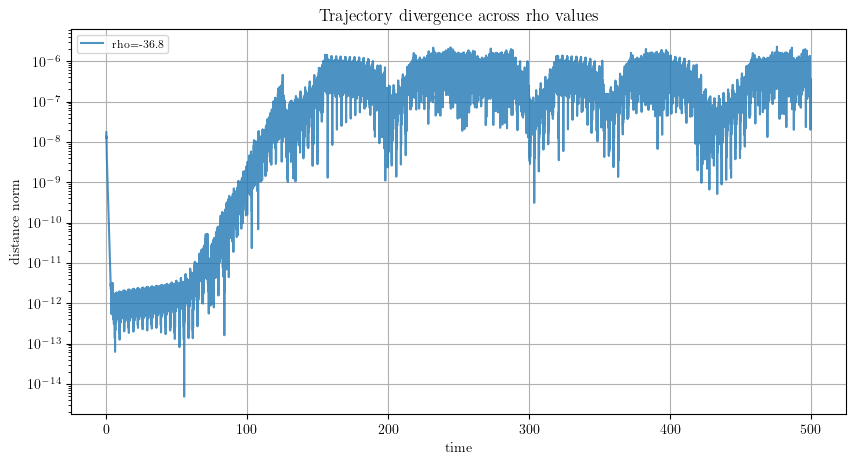

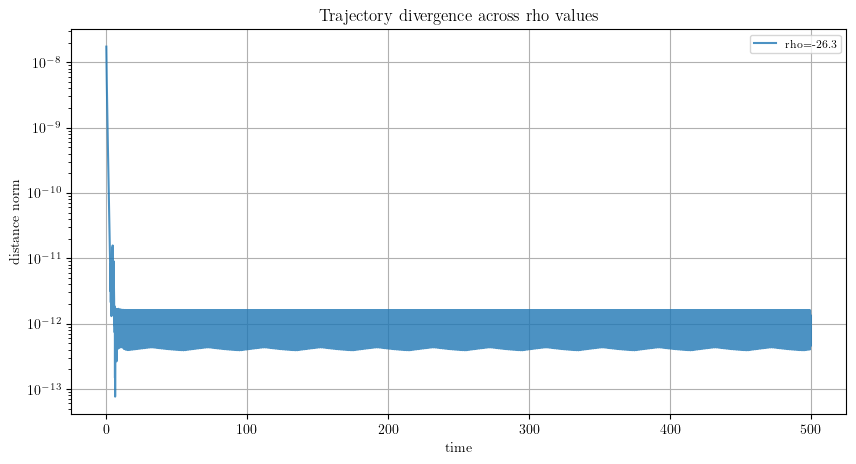

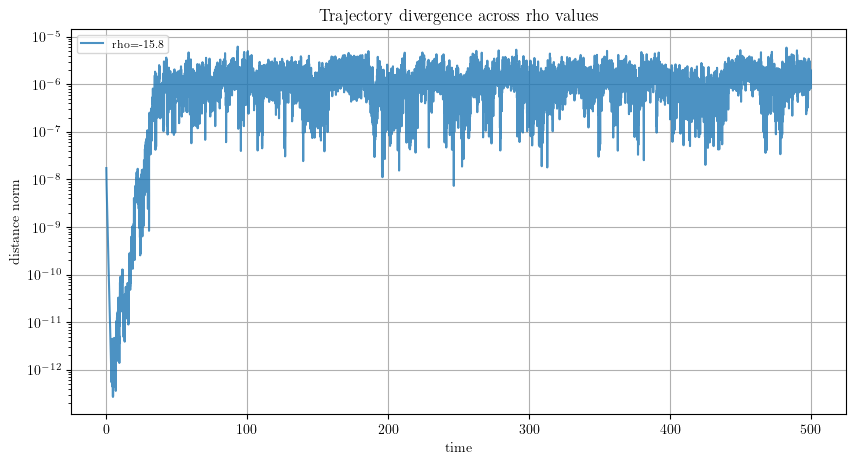

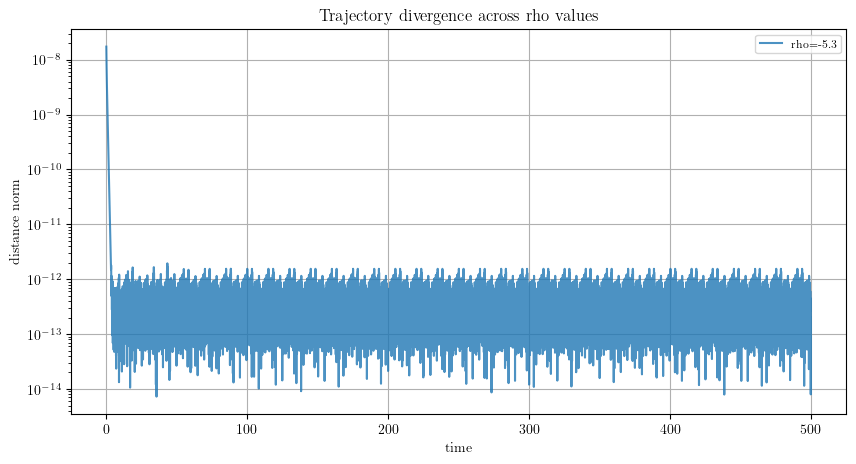

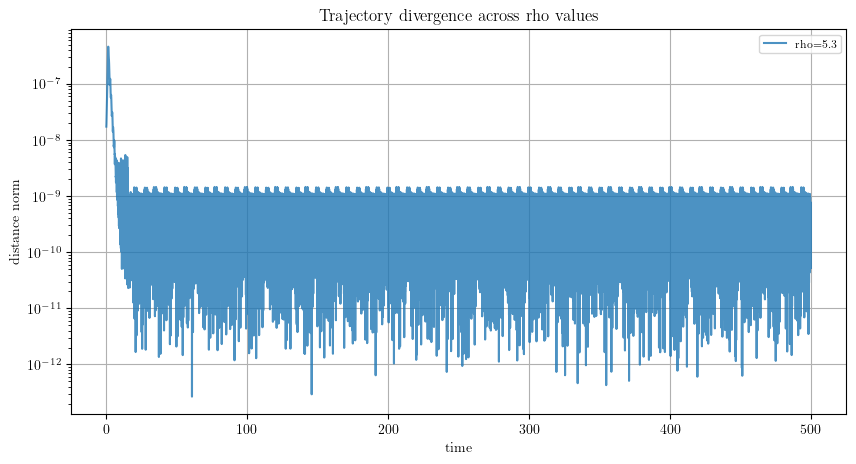

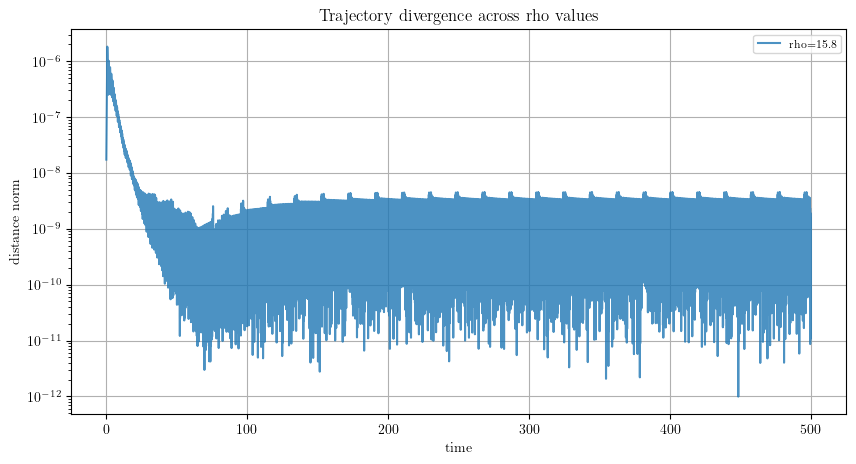

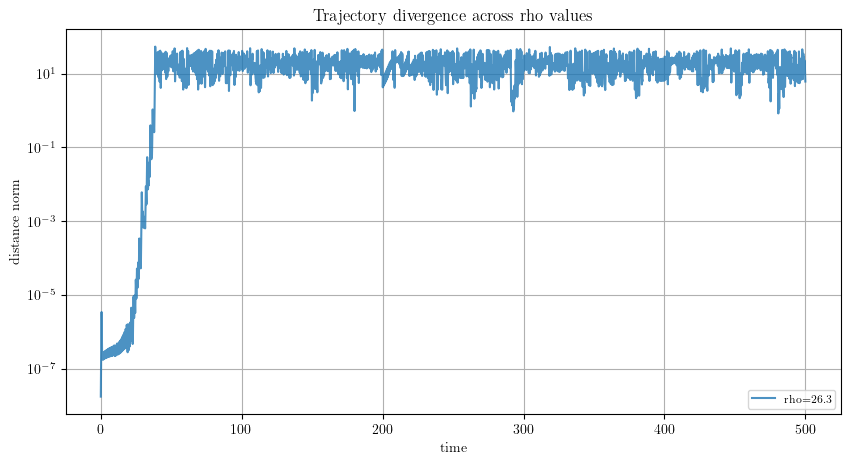

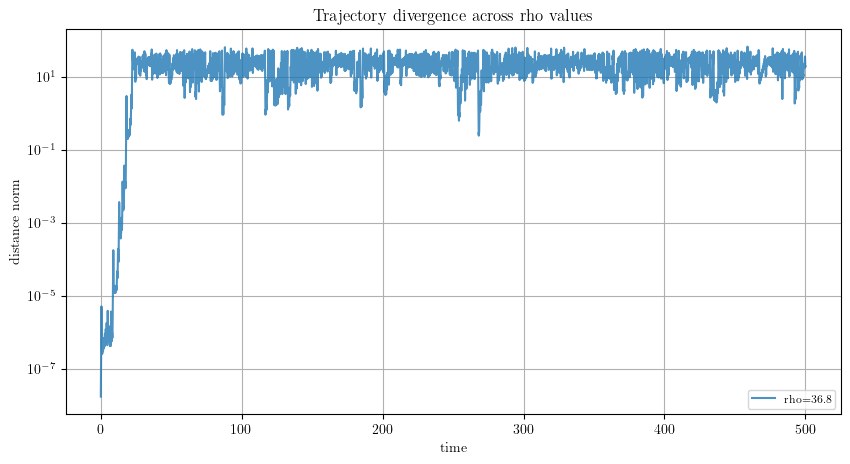

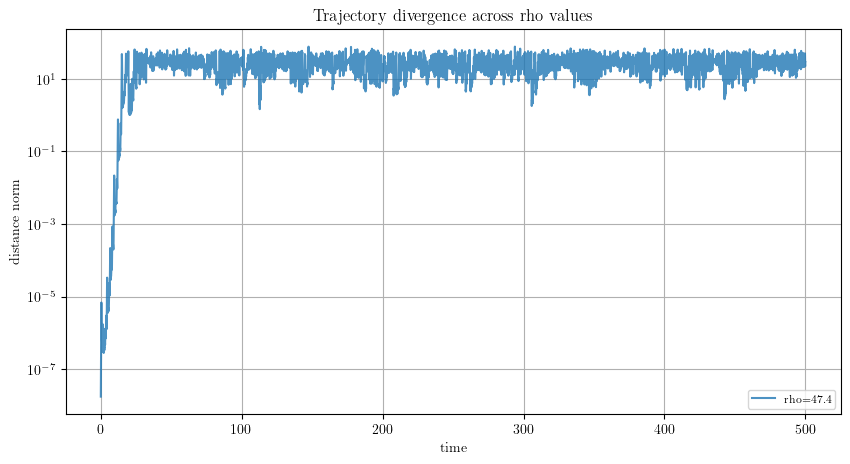

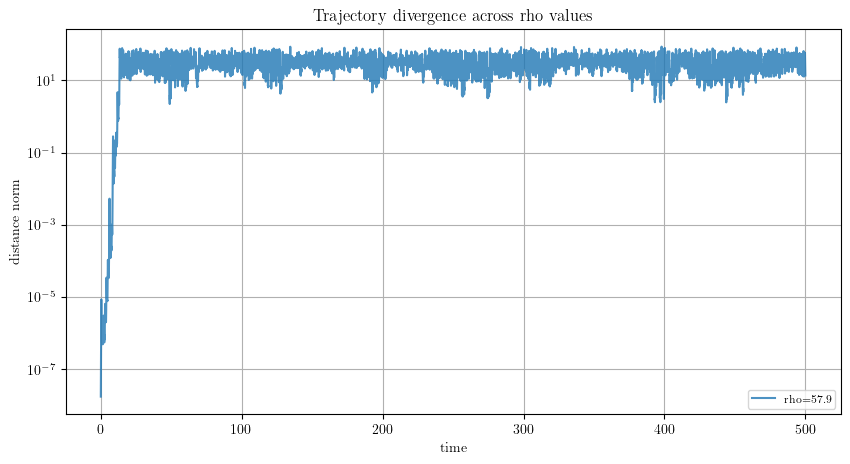

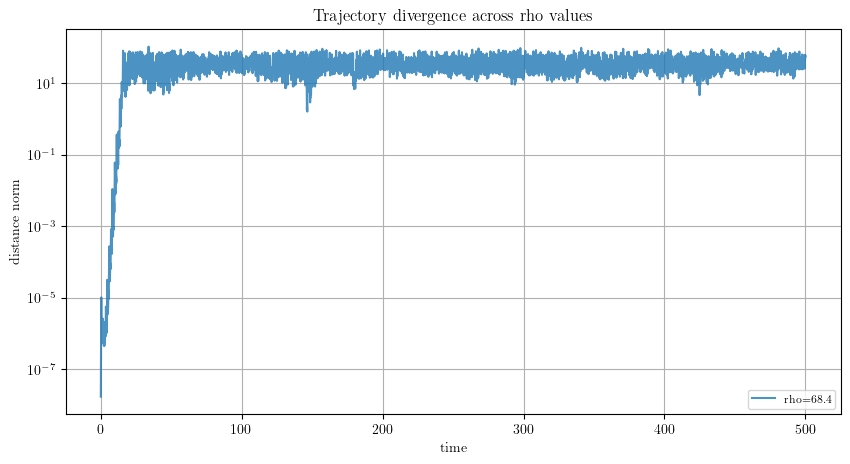

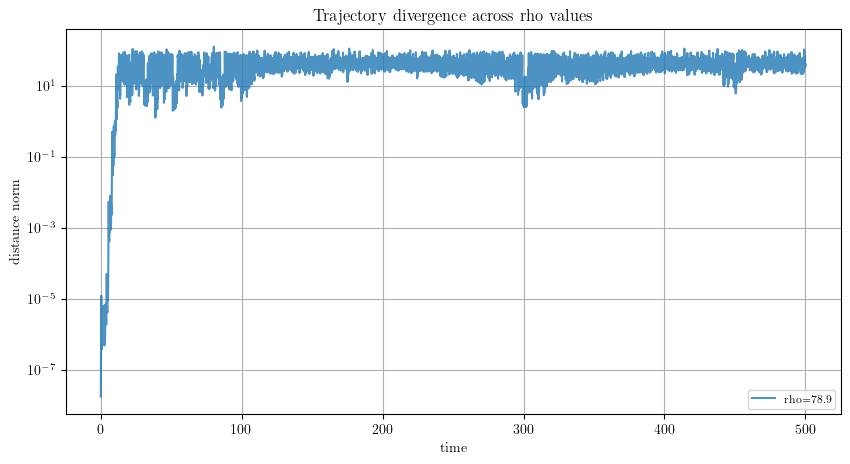

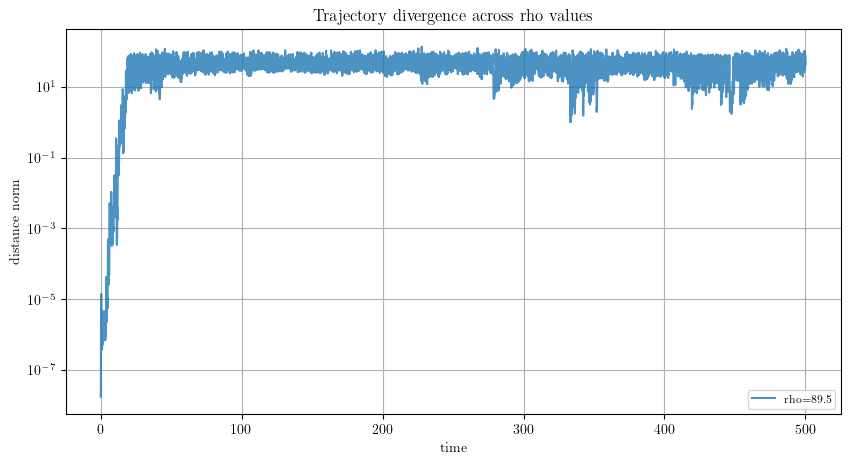

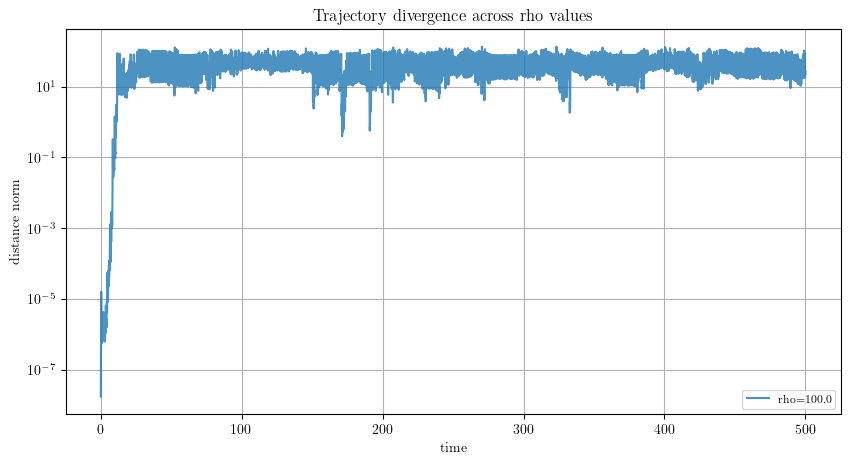

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Define model and params
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho_sample = np.linspace(-100, 100, 20)  

# Define time span 
t_span = (0, 5*10**2)
t_eval = np.linspace(t_span[0], t_span[1], 5*10**4)

# Define initial conditions
y0 = np.array([0.1, 0.1, 0.1])
eps = 1e-8
y0_perturbed = y0 + eps 

for rho in rho_sample:

    params = (sigma, beta, rho)
    binder = Binder(f"scripts.systems.{model_name}", model_name, params)
    binder.import_module()      
    model_fixed_rho = binder.fixer()

    # solve unperturbed
    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    ds1_rho.solve()

    # solve perturbed
    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    ds2_rho.solve()

    # compute distance curve
    dist = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)

    # plot each trajectory separation
    plt.figure(figsize=(10,5))
    plt.semilogy(t_eval, dist, alpha=0.8, label=f"rho={rho:.1f}")

    plt.xlabel("time")
    plt.ylabel("distance norm")
    plt.title("Trajectory divergence across rho values")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.show()

### Naive sweep

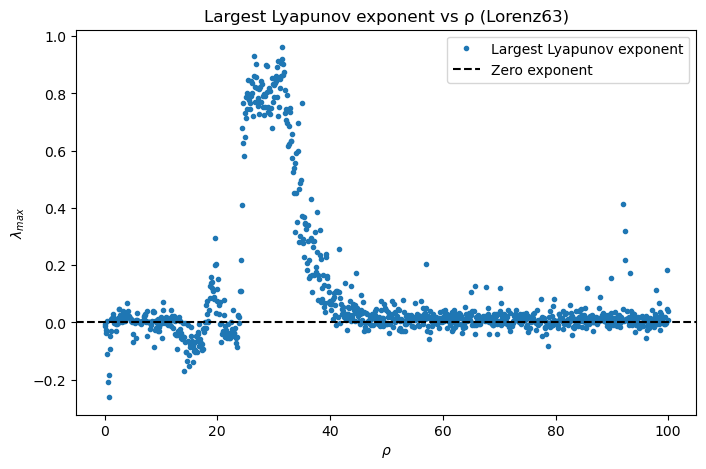

In [175]:
# Plot Lyapunov exponent vs rho
plt.figure(figsize=(8,5))
plt.plot(rho_values, lambda_max_list, '.', label='Largest Lyapunov exponent')
plt.axhline(0, color='k', linestyle='--', label='Zero exponent')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\lambda_{max}$')
plt.title('Largest Lyapunov exponent vs ρ (Lorenz63)')
plt.legend()
plt.show()

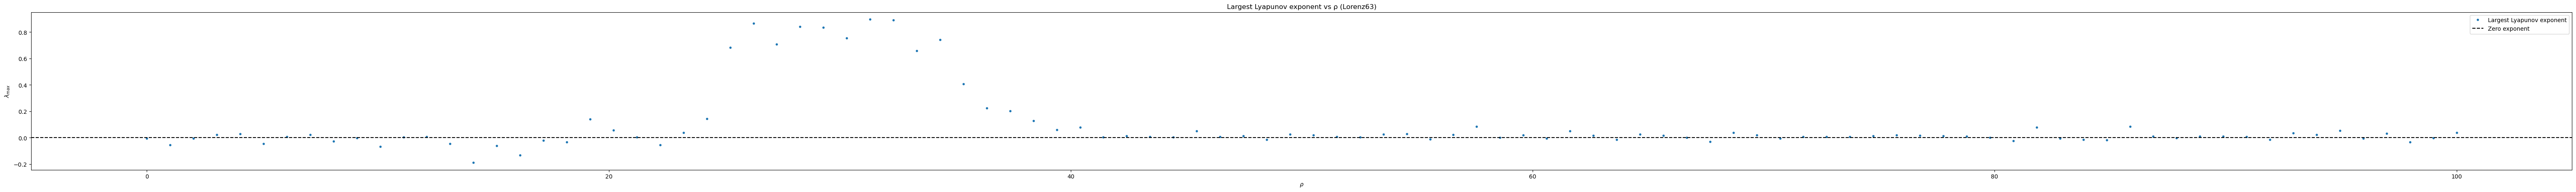

In [20]:
# Plot Lyapunov exponent vs rho
plt.figure(figsize=(80,5))
plt.plot(rho_values, lambda_max_list, '.', label='Largest Lyapunov exponent')
plt.axhline(0, color='k', linestyle='--', label='Zero exponent')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\lambda_{max}$')
plt.title('Largest Lyapunov exponent vs ρ (Lorenz63)')
plt.legend()
plt.show()


## Step 2 : Data Gathering (meaningful points)


AQUI SOLO USAMOS PRIMERO FFT AND POWER SPECTRUM


AND I THINK WE DECIDED TH ENUMBER OF PPINT USING NQYST